# 04 — Knowledge Graph Construction & Drug Target Discovery

**Pipeline Step 4 of 5**

This notebook constructs a **Micro-Clinical Knowledge Graph (Micro-CKG)** and enriches it with external biological knowledge to identify **druggable targets** from spatially-resolved biomarker genes.

### Drug Discovery Value Proposition

1. **Spatial biomarkers → Human orthologs** — map mouse Stabl-selected genes to human equivalents via HomoloGene
2. **Pathway enrichment** — identify GO biological processes and KEGG pathways that the biomarker panel converges on
3. **Drug target discovery** — query ChEMBL for approved/clinical-stage compounds targeting the orthologous human genes
4. **Spatial specificity** — Moran's I autocorrelation confirms spatial patterning (not random noise), validating therapeutic relevance

The graph follows the **Biolink Model** ontology (via BioCypher), ensuring semantic interoperability with external knowledge bases.

### Inputs
| File | Description |
|---|---|
| `data/processed/mouse_brain_preprocessed.h5ad` | QC-filtered, normalized AnnData from Step 01 |
| `cache/stabl_results_<hash>.pkl` | Stabl results from Step 02 |
| `config/schema_config.yaml` | BioCypher schema mapping (Biolink model ontology) |

### Outputs
| File | Description |
|---|---|
| `cache/micro_ckg.graphml` | Serialized Micro-CKG in GraphML format |

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.spatial_pipeline import (
    load_adata, run_stabl_cached, compute_clusters,
    annotate_clusters, assign_injury_labels,
)
from src.biocypher_adapter import build_micro_ckg, save_graph, visualize_graph
from src.spatial_analytics import (
    compute_spatial_neighbors, compute_spatial_autocorr,
    run_nhood_enrichment,
)
from src.external_knowledge import (
    map_orthologs, run_go_enrichment, get_drug_targets,
)
from src.graph_analytics import (
    detect_communities, compute_centrality, find_bridge_genes, summarise_graph,
)

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
CACHE_DIR = PROJECT_ROOT / "cache"

print("Imports ready.")

/Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports ready.


## 4.1 Load Data and Stabl Results

We reload the preprocessed AnnData and the cached Stabl results. The AnnData provides the expression matrix and spatial metadata needed to compute edge weights, while the Stabl results identify which genes become nodes in the graph and provide their stability scores as node attributes.

In [2]:
adata = load_adata(DATA_PROCESSED / "mouse_brain_preprocessed.h5ad")

stabl_result = run_stabl_cached(
    adata,
    cache_dir=CACHE_DIR,
    dataset_name="squidpy",
    n_hvgs=2000,
    label_method="cluster",
    n_bootstraps=500,
)

print(f"\n{stabl_result['n_selected']} Stabl-selected features loaded.")

  Loading dataset: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/data/processed/mouse_brain_preprocessed.h5ad
  Shape: 2691 spots × 19652 genes
  Loading cached Stabl results: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/cache/stabl_results_eba9686a7ee7.pkl

41 Stabl-selected features loaded.


## 4.2 Compute Leiden Clusters

Before building the graph, we need cell-type assignments. We apply Leiden community detection (a graph-based clustering algorithm) to the spot-level expression profiles. The procedure is: select 2,000 HVGs, compute PCA (40 components), build a k-nearest-neighbor graph (k=10), and partition the graph using the Leiden algorithm at resolution 0.8.

Each resulting cluster represents a group of spots with similar expression profiles. These clusters serve as proxy cell-type labels (e.g., neuronal subtypes, glial populations) and are used to create CellType nodes in the knowledge graph. The cluster-to-region mapping assigns anatomical labels (Cortex, Hippocampus, Thalamus, etc.) based on cluster rank order, providing spatial context for each cell-type node.

In [3]:
adata = compute_clusters(adata, n_hvgs=2000)
print(f"\nLeiden clusters: {adata.obs['leiden'].nunique()}")
print(adata.obs["leiden"].value_counts().sort_index())

# Annotate clusters with brain-region marker gene signatures
cluster_annotation = annotate_clusters(adata)
print("\nCluster annotations:")
for cid, region in sorted(cluster_annotation.items(), key=lambda x: int(x[0])):
    print(f"  Cluster {cid} → {region}")

# Assign injury labels based on neuroinflammation scoring
injury_labels = assign_injury_labels(adata)
n_reactive = int(injury_labels.sum())
n_homeo = len(injury_labels) - n_reactive
print(f"\nInjury labels: {n_reactive} reactive / {n_homeo} homeostatic spots")

  Selected 2000 highly variable genes (requested 2000)


/Users/shaunfchen/.local/share/uv/python/cpython-3.11.15-macos-aarch64-none/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


  Leiden clustering: 17 clusters

Leiden clusters: 17
leiden
0      64
1     198
2     194
3     103
4     114
5     220
6     291
7     337
8     124
9     130
10    207
11    205
12     36
13    259
14     48
15     70
16     91
Name: count, dtype: int64
  Cluster annotation: {'White_Matter': np.int64(9), 'Cortex': np.int64(4), 'Hippocampus': np.int64(2), 'Thalamus': np.int64(1), 'Cerebellum': np.int64(1)}

Cluster annotations:
  Cluster 0 → Cortex
  Cluster 1 → Cortex
  Cluster 2 → White_Matter
  Cluster 3 → Thalamus
  Cluster 4 → White_Matter
  Cluster 5 → White_Matter
  Cluster 6 → Cortex
  Cluster 7 → Cortex
  Cluster 8 → Cerebellum
  Cluster 9 → White_Matter
  Cluster 10 → White_Matter
  Cluster 11 → White_Matter
  Cluster 12 → Hippocampus
  Cluster 13 → White_Matter
  Cluster 14 → White_Matter
  Cluster 15 → Hippocampus
  Cluster 16 → White_Matter
  Neuroinflammation scoring (12 markers): 1346 reactive / 1345 homeostatic spots

Injury labels: 1346 reactive / 1345 homeostatic sp

## 4.3 Build Micro-CKG (DE-Filtered)

The knowledge graph now uses **Wilcoxon rank-sum differential expression testing** to create statistically significant edges instead of simple expression thresholds:

**Filtering criteria:**
- Gene → CellType edges require adjusted p-value < 0.05 AND |log2FC| > 0.5
- Gene → Region edges are aggregated from DE-significant cluster-level associations
- This reduces the graph from ~1000 noisy edges to a sparse, biologically meaningful network

**Edge attributes now include:**
- `log2fc` — log2 fold change from DE test
- `pval_adj` — Benjamini-Hochberg adjusted p-value
- `stability_score` — Stabl bootstrap stability score
- `mean_expression` — mean expression in the cluster

In [4]:
schema_path = PROJECT_ROOT / "config" / "schema_config.yaml"

graph = build_micro_ckg(
    stabl_result=stabl_result,
    adata=adata,
    schema_path=schema_path,
    cluster_annotation=cluster_annotation,
)

print(f"\nMicro-CKG:")
print(f"  Nodes: {graph.number_of_nodes()}")
print(f"  Edges: {graph.number_of_edges()}")

# Quick topology summary
summary = summarise_graph(graph)
print(f"  Density: {summary['density']:.4f}")
print(f"  Components: {summary['n_components']}")

  Running DE testing (Wilcoxon rank-sum)...
  DE results: 697 tests, 426 significant
  Building Micro-CKG...
  Micro-CKG: 63 nodes (41 genes, 17 cell types, 5 regions)
  Micro-CKG: 601 edges (DE-filtered)

Micro-CKG:
  Nodes: 63
  Edges: 601
  Graph summary: 63 nodes, 601 edges, density=0.1539, 1 components
  Density: 0.1539
  Components: 1


## 4.4 Graph Analytics & Drug Discovery Dashboard

Multi-panel visualization showing:
- **Top hub genes** — the most connected biomarkers and their cell-type/region associations
- **Gene × Region heatmap** — which biomarkers are spatially specific to which brain regions
- **Centrality ranking** — PageRank identifies the most influential genes in the network
- **Edge composition** — breakdown of relationship types in the knowledge graph

  Communities: 5 detected via Louvain
  Centrality computed for 63 nodes
  Communities: 5 detected via Louvain
  Bridge genes: 40/41 genes bridge >1 community
Top 10 hub genes by PageRank:
              degree  betweenness  pagerank
gene:Cpne6        18     0.007080  0.007483
gene:Kcnip2       17     0.006056  0.007483
gene:Lrrc10b      15     0.004574  0.007483
gene:Ctxn3        14     0.003203  0.007483
gene:Gm42418       7     0.000696  0.007483
gene:Pcp4         12     0.002425  0.007483
gene:Igfbp6       17     0.005714  0.007483
gene:Pcdh20       13     0.003326  0.007483
gene:Pcdh8        15     0.004091  0.007483
gene:Scg2         17     0.006071  0.007483

Bridge genes (connect multiple graph communities):
        gene  bridge_score  n_communities_bridged  betweenness
   gene:Hpca      0.018984                      5     0.010595
gene:Slc30a3      0.013847                      5     0.007728
  gene:Cpne6      0.012686                      5     0.007080
 gene:Hpcal1      0.012

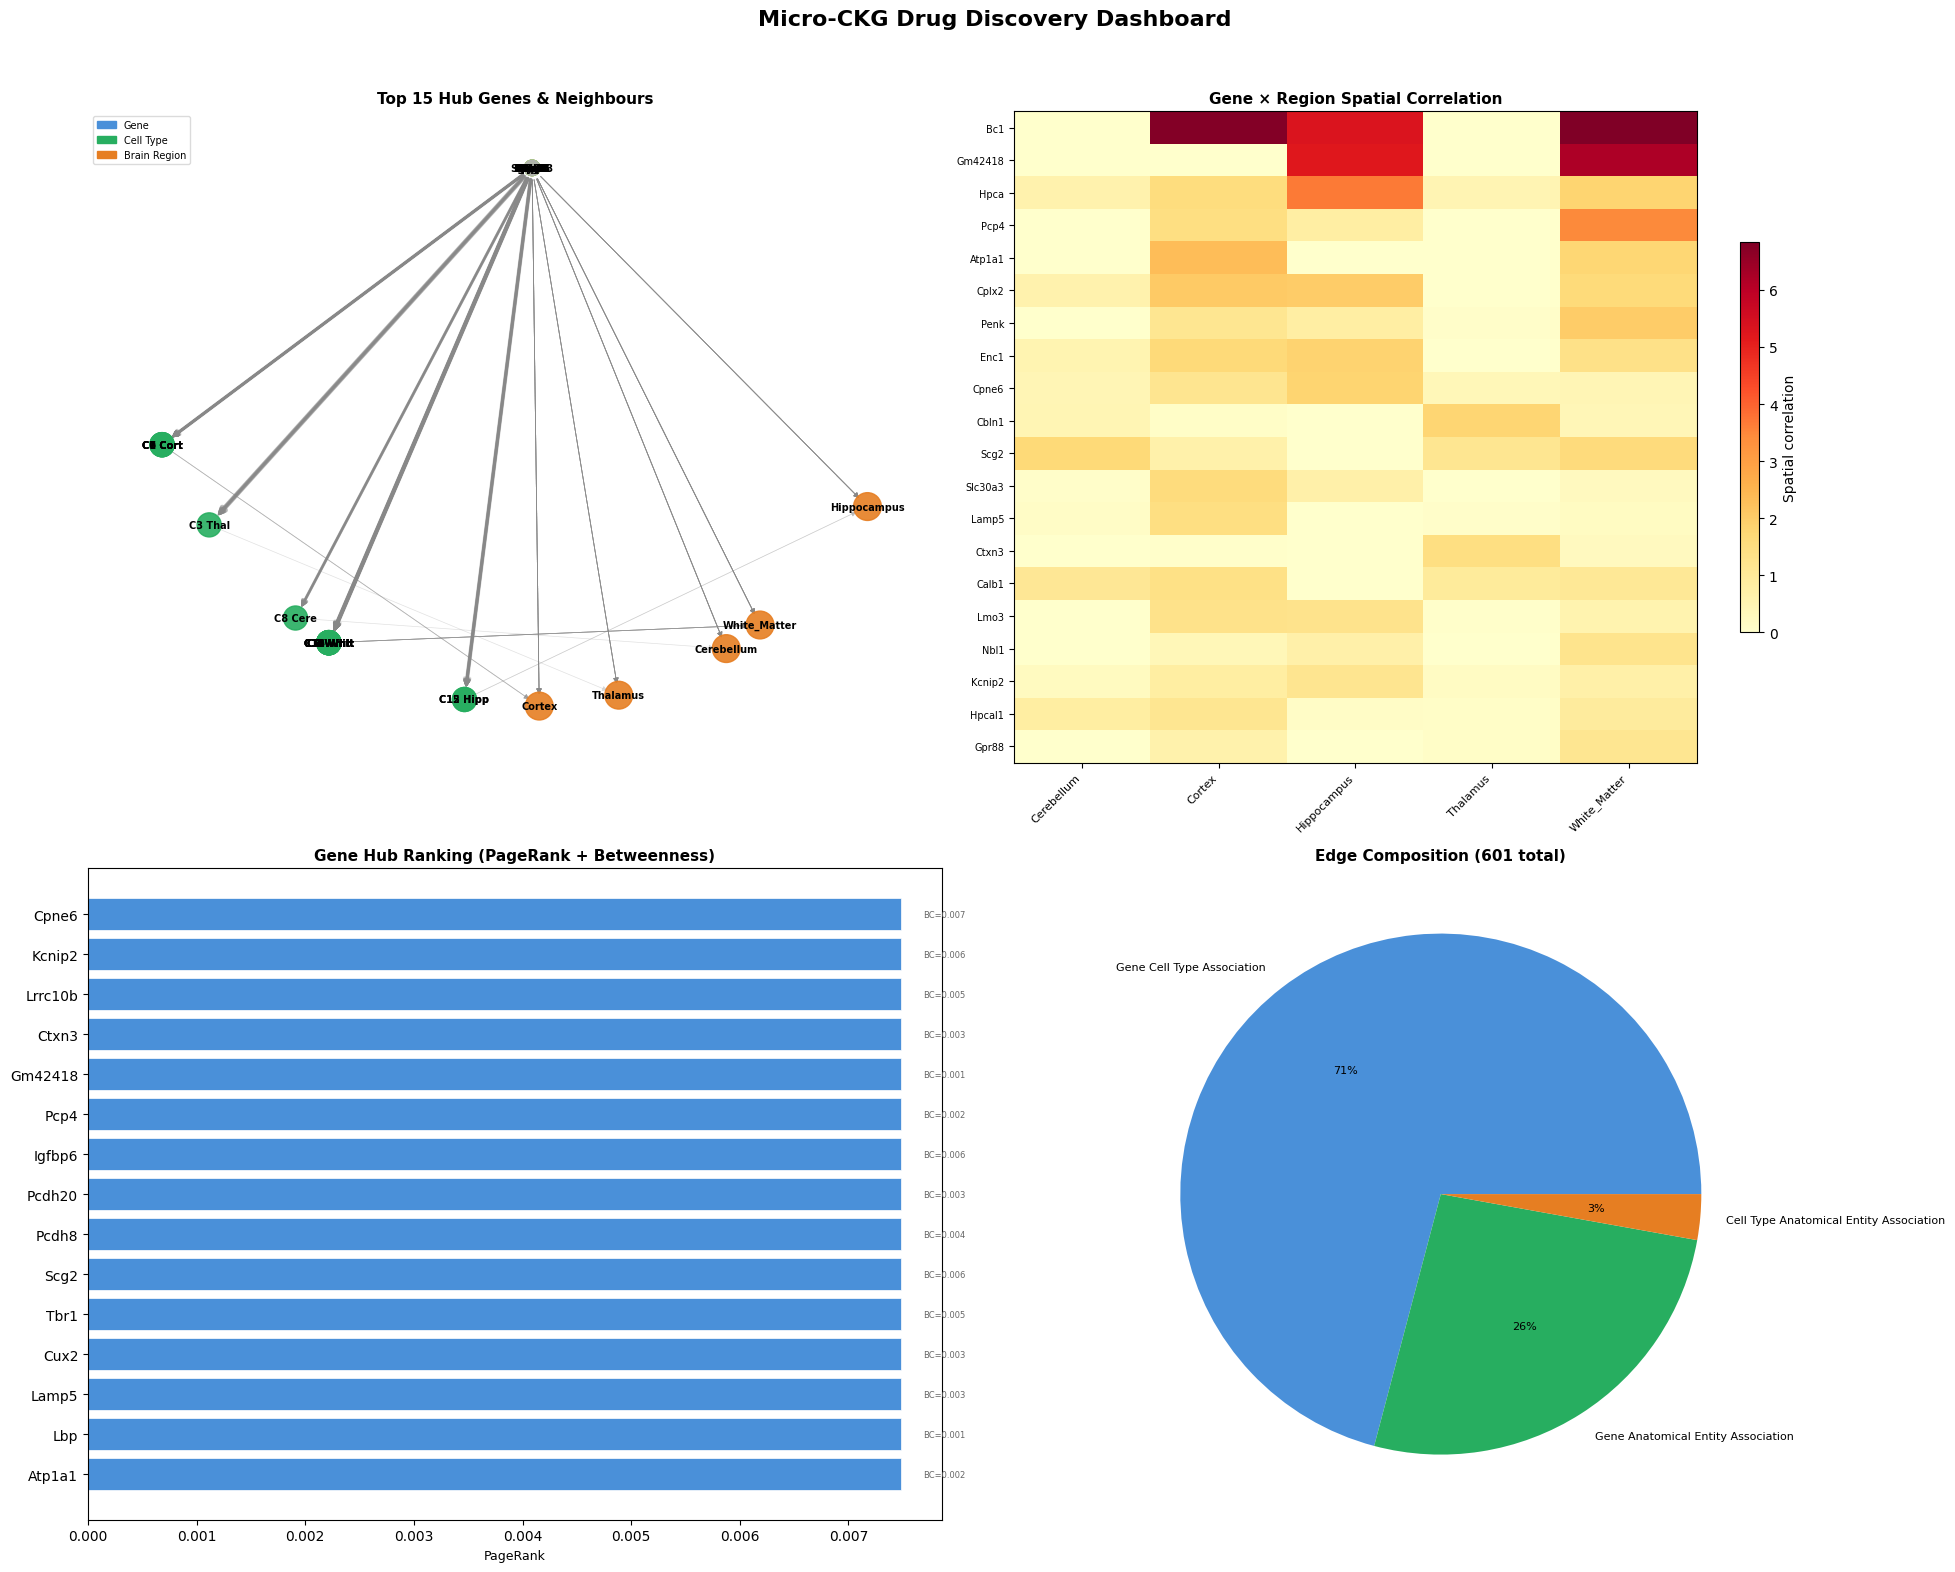

In [5]:
# Community detection & centrality
community_map = detect_communities(graph)
centrality_df = compute_centrality(graph)
bridge_df = find_bridge_genes(graph, centrality_df)

print("Top 10 hub genes by PageRank:")
gene_centrality = centrality_df[centrality_df["label"] == "gene"].head(10)
print(gene_centrality[["degree", "betweenness", "pagerank"]].to_string())

print("\nBridge genes (connect multiple graph communities):")
print(bridge_df.head(10)[["gene", "bridge_score", "n_communities_bridged", "betweenness"]].to_string(index=False))

# Multi-panel drug discovery dashboard
visualize_graph(graph, community_map=community_map, centrality_df=centrality_df)

## 4.5 Save Graph

The Micro-CKG is serialized to GraphML format, a standard XML-based graph format supported by NetworkX, Cytoscape, Neo4j, and other graph analysis tools. This file serves as the input to the LLM agent in Step 05 and can also be loaded into graph visualization software for interactive exploration.

In [6]:
graph_path = save_graph(graph, CACHE_DIR / "micro_ckg.graphml")
print(f"\nGraph persisted: {graph_path}")
print(f"File size: {graph_path.stat().st_size / 1e3:.1f} KB")

  Graph saved to /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/cache/micro_ckg.graphml

Graph persisted: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/cache/micro_ckg.graphml
File size: 201.4 KB


## 4.6 Spatial Validation (Moran's I)

**Why this matters for drug development:** A biomarker is only therapeutically relevant if its spatial expression pattern is non-random. Moran's I > 0 with p < 0.05 confirms that a gene shows **spatially clustered expression** — it marks a real tissue compartment, not noise. This spatial specificity is critical for targeted drug delivery.

In [7]:
# Build spatial neighbourhood graph
adata = compute_spatial_neighbors(adata, n_neighs=6)

# Spatial autocorrelation — test Stabl-selected genes
moran_df = compute_spatial_autocorr(
    adata,
    genes=stabl_result["selected_genes"],
    mode="moran",
    n_perms=100,
)

# Show top spatially autocorrelated genes
sig_moran = moran_df[moran_df["pval_norm"] < 0.05].sort_values("I", ascending=False)
print(f"\nTop spatially autocorrelated Stabl genes (Moran's I):")
print(f"({len(sig_moran)}/{len(stabl_result['selected_genes'])} genes spatially significant)\n")
print(sig_moran.head(15)[["I", "pval_norm"]].to_string())

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
  Spatial neighbours computed (n_neighs=6)


100%|██████████| 100/100 [00:03<00:00, 32.67/s]


  Spatial autocorrelation (moran): 41/41 genes significant (p < 0.05)

Top spatially autocorrelated Stabl genes (Moran's I):
(41/41 genes spatially significant)

                I  pval_norm
Pcp4     0.766880        0.0
Ctxn3    0.731801        0.0
Cbln1    0.709799        0.0
Cplx2    0.697515        0.0
Hpca     0.693487        0.0
Lamp5    0.682915        0.0
Slc30a3  0.678126        0.0
Penk     0.654334        0.0
Atp1a1   0.646910        0.0
Hpcal1   0.642982        0.0
Tbr1     0.629903        0.0
Enc1     0.605177        0.0
Gpr88    0.583625        0.0
Igfbp6   0.575755        0.0
Tac1     0.567256        0.0


## 4.7 Translational Drug Target Discovery

This is the key drug-development step. We take the spatially-validated mouse biomarker genes and:
1. **Map to human orthologs** — mouse gene symbols → human equivalents via HomoloGene
2. **Pathway enrichment** — what GO biological processes / KEGG pathways do these genes converge on?
3. **Drug target query** — which human orthologs have approved or clinical-stage drugs in ChEMBL?

This creates a direct pipeline from spatial transcriptomics → druggable targets.

In [8]:
# Mouse → Human ortholog mapping
ortho_df = map_orthologs(stabl_result["selected_genes"])
human_genes = ortho_df["human_symbol"].dropna().tolist()
print(f"Mapped {len(human_genes)} / {len(stabl_result['selected_genes'])} genes to human orthologs")
display(ortho_df.head(10))

# GO / KEGG pathway enrichment
enrich_df = run_go_enrichment(human_genes)
if enrich_df is not None and not enrich_df.empty:
    print(f"\nTop enriched pathways ({len(enrich_df)} total):")
    display(enrich_df.head(15))
else:
    print("\nNo significant enrichment results returned.")

# ChEMBL drug target lookup
drug_df = get_drug_targets(human_genes)
if drug_df is not None and not drug_df.empty:
    print(f"\nDruggable targets found: {drug_df['gene'].nunique()} genes, {len(drug_df)} drug associations")
    display(drug_df.head(15))
else:
    print("\nNo drug targets found in ChEMBL for these genes.")

  Orthologs loaded from cache (38 mappings)
Mapped 38 / 41 genes to human orthologs


,mouse_symbol,human_symbol,human_entrezgene,ensembl_gene
0,Wnt4,WNT4,54361,ENSG00000162552
1,Stxbp6,STXBP6,29091,ENSG00000168952
2,Enc1,ENC1,8507,ENSG00000171617
3,Pcdh20,PCDH20,64881,ENSG00000197991
4,Cpne6,CPNE6,9362,ENSG00000100884
5,Cbln1,CBLN1,869,ENSG00000102924
6,Cux2,CUX2,23316,ENSG00000111249
7,Pcdh8,PCDH8,5100,ENSG00000136099
8,Kcnip2,KCNIP2,30819,ENSG00000120049
9,Scg2,SCG2,7857,ENSG00000171951


  GO enrichment loaded from cache

Top enriched pathways (487 total):


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Gene_set_library
0,GO_Biological_Process_2023,Negative Regulation Of Steroid Biosynthetic Pr...,2/10,0.000157,0.027703,0,0,138.569444,1214.062108,DKKL1;WNT4,GO_Biological_Process_2023
1,GO_Biological_Process_2023,Memory (GO:0007613),3/58,0.000182,0.027703,0,0,31.023896,267.220949,CUX2;CALB1;TAFA2,GO_Biological_Process_2023
2,GO_Biological_Process_2023,Regulation Of Insulin-Like Growth Factor Recep...,2/19,0.000589,0.055538,0,0,65.179739,484.753460,IGFBP4;IGFBP6,GO_Biological_Process_2023
3,GO_Biological_Process_2023,Muscle Contraction (GO:0006936),3/94,0.000753,0.055538,0,0,18.716797,134.604908,KCNIP2;NOS1;MYH7,GO_Biological_Process_2023
4,GO_Biological_Process_2023,Negative Regulation Of Canonical Wnt Signaling...,3/114,0.001316,0.055538,0,0,15.328958,101.683070,IGFBP4;DKKL1;IGFBP6,GO_Biological_Process_2023
5,GO_Biological_Process_2023,Cardiac Muscle Cell Action Potential (GO:0086001),2/29,0.001382,0.055538,0,0,41.018519,270.084965,KCNIP2;ATP1A1,GO_Biological_Process_2023
6,GO_Biological_Process_2023,Regulation Of Potassium Ion Transport (GO:0043...,2/30,0.001479,0.055538,0,0,39.551587,257.744565,KCNIP2;NOS1,GO_Biological_Process_2023
7,GO_Biological_Process_2023,Modulation Of Excitatory Postsynaptic Potentia...,2/31,0.001579,0.055538,0,0,38.185824,246.343366,CUX2;CBLN1,GO_Biological_Process_2023
8,GO_Biological_Process_2023,Negative Regulation Of Small Molecule Metaboli...,2/33,0.001788,0.055538,0,0,35.718638,225.974224,DKKL1;WNT4,GO_Biological_Process_2023
9,GO_Biological_Process_2023,Regulation Of Metal Ion Transport (GO:0010959),2/34,0.001898,0.055538,0,0,34.600694,216.845284,ATP1A1;NOS1,GO_Biological_Process_2023


  Drug targets loaded from cache (15 entries)

Druggable targets found: 5 genes, 15 drug associations


,gene,drug_name,mechanism_of_action,max_phase
0,SCG2,REVUMENIB CITRATE,Menin inhibitor,4.0
1,LPL,NEIHULIZUMAB,P-selectin glycoprotein ligand 1 inhibitor,2.0
2,TAC1,APREPITANT,Neurokinin 1 receptor antagonist,4.0
3,TAC1,FOSAPREPITANT DIMEGLUMINE,Neurokinin 1 receptor antagonist,4.0
4,TAC1,NETUPITANT,Neurokinin 1 receptor antagonist,4.0
5,TAC1,ROLAPITANT HYDROCHLORIDE,Neurokinin 1 receptor antagonist,4.0
6,TAC1,FIGOPITANT,Neurokinin 1 receptor antagonist,2.0
7,CNR1,NABILONE,Cannabinoid CB1 receptor agonist,4.0
8,CNR1,DRONABINOL,Cannabinoid CB1 receptor agonist,4.0
9,CNR1,SAD448,Cannabinoid CB1 receptor agonist,1.0
